## **UA Innovate 2026: Using Data to Evaluate Network Costs and Identify Opportunities for Improvement/Optimization**

In [18]:
# --- Default libraries ---
import os
import warnings
from pathlib import Path

# --- Working directory ---
PROJECT_DIR = Path().resolve()
PROJECT_ROOT_NAME = 'ua-innovate-2026'

while PROJECT_DIR.name != PROJECT_ROOT_NAME and PROJECT_DIR != PROJECT_DIR.parent:
    PROJECT_DIR = PROJECT_DIR.parent

if Path().resolve() != PROJECT_DIR:
    os.chdir(PROJECT_DIR)

DATA_DIR = PROJECT_DIR / 'data'
LOG_DIR = PROJECT_DIR / 'logs'

# --- Custom modules ---
from src.utils import set_seed
from src.utils.data import (
    apply_filter,
    clean_device_dataset,
    get_device_dataset,
    wrangle
)
from src.utils.viz import (
    plot_top_overdue_sites,
    generate_appendix_visual_suite
)

# --- Settings ---
warnings.filterwarnings('ignore')
set_seed(42)

### **1. Exploratory Data Analysis**

In [2]:
# Read in the Excel tabs
sheets = wrangle(excel_filepath=DATA_DIR / 'UAInnovateDataset-SoCo.xlsx')
sheets.keys()

dict_keys(['SOLID', 'SOLID-Loc', 'NA', 'PrimeAP', 'PrimeWLC', 'CatCtr', 'Decom', 'ModelData', 'Pricing', 'Glossary'])

In [3]:
# Check the shapes of the original sheets
for sheet_name, df in sheets.items():
    print(f"Sheet: {sheet_name}, Shape: {df.shape}")

Sheet: SOLID, Shape: (3630, 7)
Sheet: SOLID-Loc, Shape: (3631, 7)
Sheet: NA, Shape: (9395, 16)
Sheet: PrimeAP, Shape: (565, 19)
Sheet: PrimeWLC, Shape: (7, 17)
Sheet: CatCtr, Shape: (11679, 45)
Sheet: Decom, Shape: (6, 3)
Sheet: ModelData, Shape: (167, 24)
Sheet: Pricing, Shape: (133, 9)
Sheet: Glossary, Shape: (98, 3)


In [4]:
# Get the devices in 'NA' that exist in 'PrimeAP'
sheets['NA'][sheets['NA']['Host Name'].isin(sheets['PrimeAP']['name'])]

,Host Name,Device IP,Device Type,Device Status,Device Vendor,Device Model,Serial Number,Software Version,Firmware Version,Free Ports,Total Ports,Ports In Use,Uptime,Last Successful Snapshot,Last Snapshot Attempt,Last Snapshot Result


In [5]:
# Get the devices in 'NA' that exist in 'PrimeWLC'
sheets['NA'][sheets['NA']['Host Name'].isin(sheets['PrimeWLC']['deviceName'])]

,Host Name,Device IP,Device Type,Device Status,Device Vendor,Device Model,Serial Number,Software Version,Firmware Version,Free Ports,Total Ports,Ports In Use,Uptime,Last Successful Snapshot,Last Snapshot Attempt,Last Snapshot Result
4420,GAXGPWLLAB03,158.128.223.253,WirelessLC,Active,Cisco,AIR-CT5520-K9,QCH3788W785,8.20.290.0,9.3.307.0,0,6,6,137d:14h:51m:37s,Jun-14-24 01:17:52,Jan-23-26 02:27:28,Problem accessing device


In [6]:
# Apply all the filters required in the prompt to the sheets
sheets = apply_filter(sheets)

Decommissioned sites in 'SOLID' sheet: 6

Unreachable devices in 'CatCtr' sheet: 443

Devices in 'CatCtr' sheet with no hostname: 3

Devices in 'NA' sheet that are present in 'CatCtr' sheet: 189
Devices in 'PrimeAP' sheet that are present in 'CatCtr' sheet: 148
Devices in 'PrimeWLC' sheet that are present in 'CatCtr' sheet: 0

Devices in 'NA' sheet that are present in 'PrimeAP' sheet: 0
Devices in 'NA' sheet that are present in 'PrimeWLC' sheet: 1

Inactive devices in 'NA' sheet: 329
Number of devices filtered out in 'NA' sheet based on 'Device Type': 50

Number of device categories filtered out in 'ModelData' sheet: 5


In [7]:
# Check the 'Device Type' column in the 'NA' sheet
sheets['NA']['Device Type'].value_counts()

Device Type
Switch           5264
Router           3470
Voice Gateway      92
Name: count, dtype: int64

In [8]:
sheets['NA']['Device Status'].value_counts()

Device Status
Active            8410
Pre-Production     416
Name: count, dtype: int64

In [9]:
# Check the shapes of the filtered sheets
for sheet_name, df in sheets.items():
    print(f"Sheet: {sheet_name}, Shape: {df.shape}")

Sheet: SOLID, Shape: (3624, 7)
Sheet: SOLID-Loc, Shape: (3625, 7)
Sheet: NA, Shape: (8826, 16)
Sheet: PrimeAP, Shape: (417, 19)
Sheet: PrimeWLC, Shape: (7, 17)
Sheet: CatCtr, Shape: (11233, 45)
Sheet: Decom, Shape: (6, 3)
Sheet: ModelData, Shape: (162, 24)
Sheet: Pricing, Shape: (133, 9)
Sheet: Glossary, Shape: (98, 3)


In [10]:
# Get the sites that are only in 'SOLID' and not in 'SOLID-Loc'
sheets['SOLID'][~sheets['SOLID']['Site Code'].isin(sheets['SOLID-Loc']['Site Code'])]

,Site Code,Site Name,Street Address 1,Street Address 2,City,State,Zip


In [11]:
# Get the sites that are only in 'SOLID-Loc' and not in 'SOLID'
sheets['SOLID-Loc'][~sheets['SOLID-Loc']['Site Code'].isin(sheets['SOLID']['Site Code'])]

,Latitude,Longitude,PhysicalAddressCounty,Call Group,Site Code,Site Name,Owner
1475,30.4146,-87.20269,NaN,FO-FL-FPL SERVICE DESK BLT HUB 1,XFP,FPC - Corporate Headquarters,NextEra


In [12]:
# Get the dataset with each row as a device
device_dataset = get_device_dataset(sheets)
device_dataset.shape

(19235, 71)

In [13]:
# Save the device dataset to a CSV file
device_dataset.to_csv(DATA_DIR / 'device_dataset.csv', index=False)

In [14]:
# Clean the device dataset
device_dataset = clean_device_dataset(device_dataset)

In [15]:
device_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19235 entries, 0 to 19234
Data columns (total 60 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   device_name                 19235 non-null  object 
 1   device_source               19235 non-null  object 
 2   source_device_id            19235 non-null  string 
 3   state_code                  19235 non-null  object 
 4   site_code                   19235 non-null  object 
 5   location_matched            19235 non-null  bool   
 6   loc_state                   18845 non-null  string 
 7   loc_site_code               18845 non-null  string 
 8   loc_site_name               18830 non-null  object 
 9   loc_address_1               18845 non-null  object 
 10  loc_city                    18845 non-null  object 
 11  loc_zip                     18845 non-null  object 
 12  loc_county                  17955 non-null  object 
 13  loc_call_group              188

### **2. Visualization**

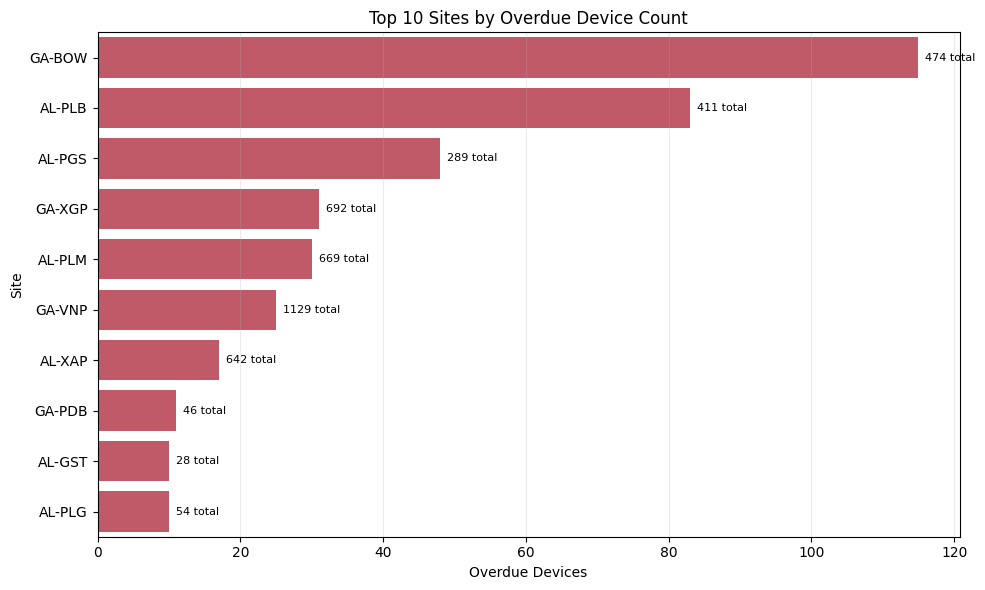

In [16]:
# Visualize the top sites with overdue EoL
fig, out = plot_top_overdue_sites(
    device_dataset=device_dataset,
    horizon_days=365,
    savefig=False,
    filename='top10_overdue_sites.png'
)

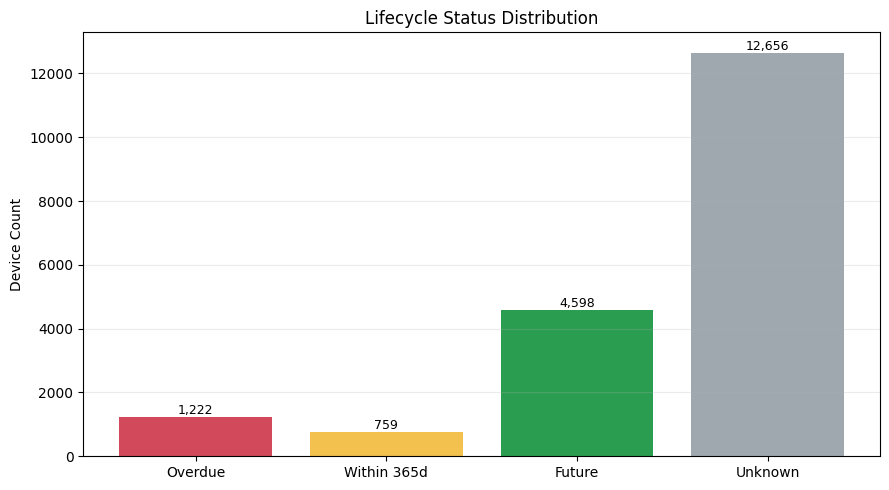

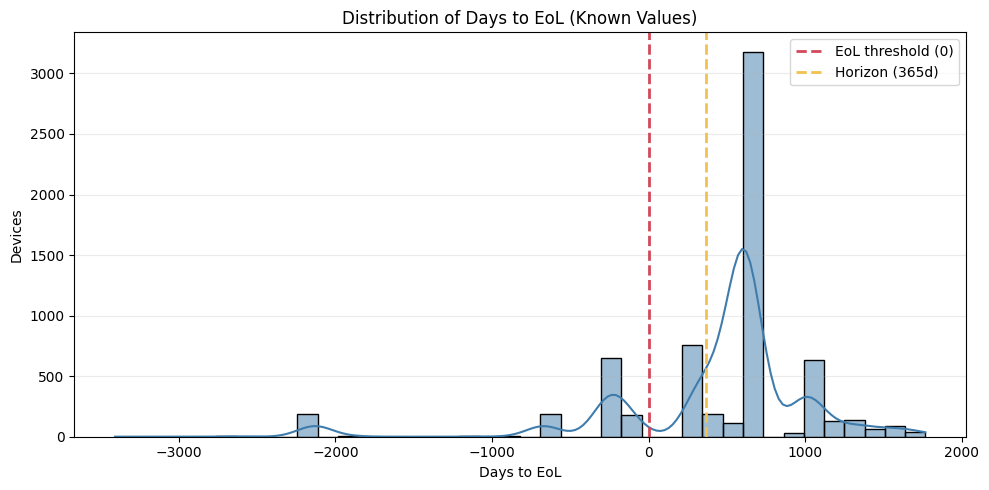

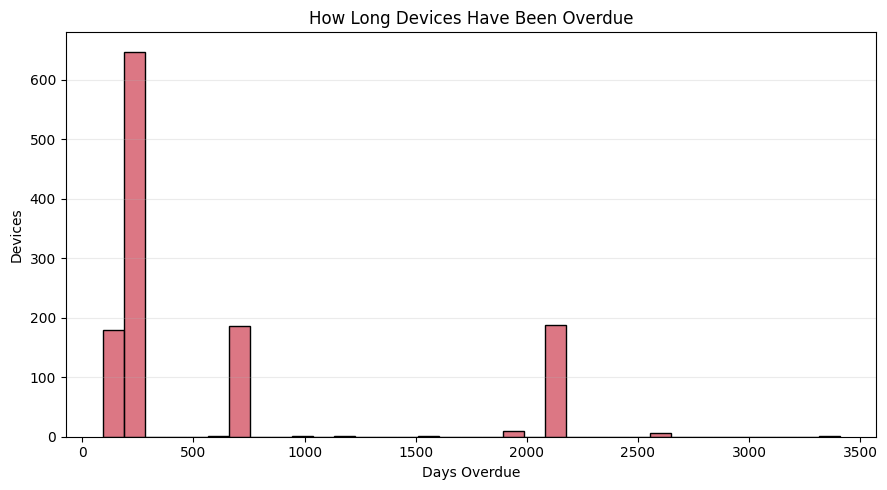

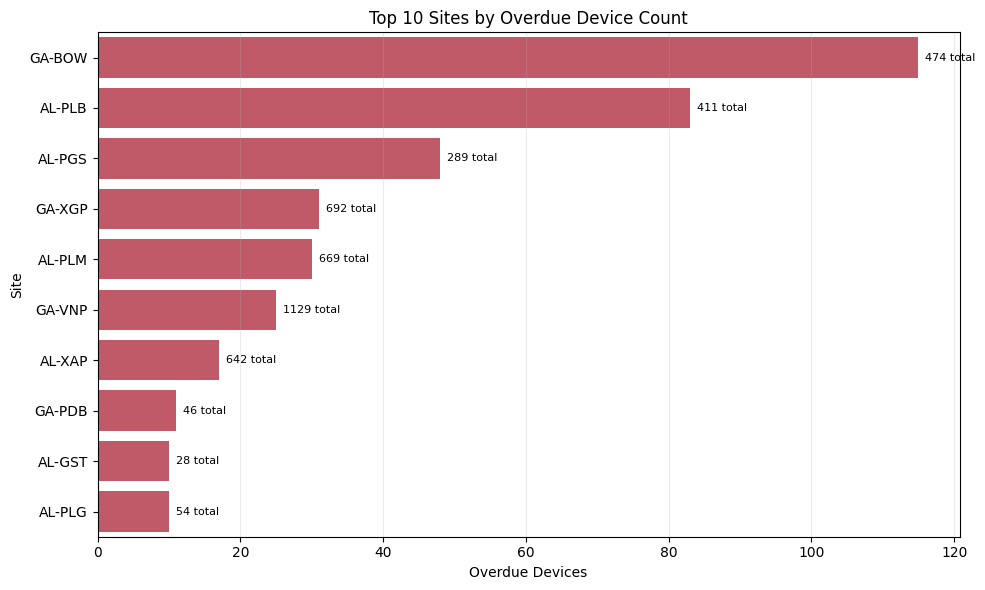

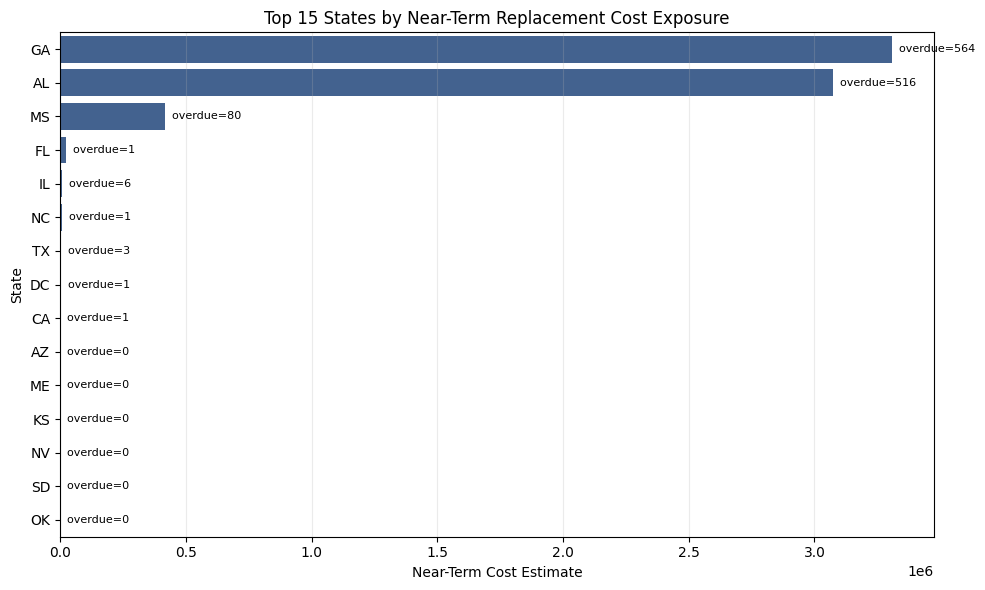

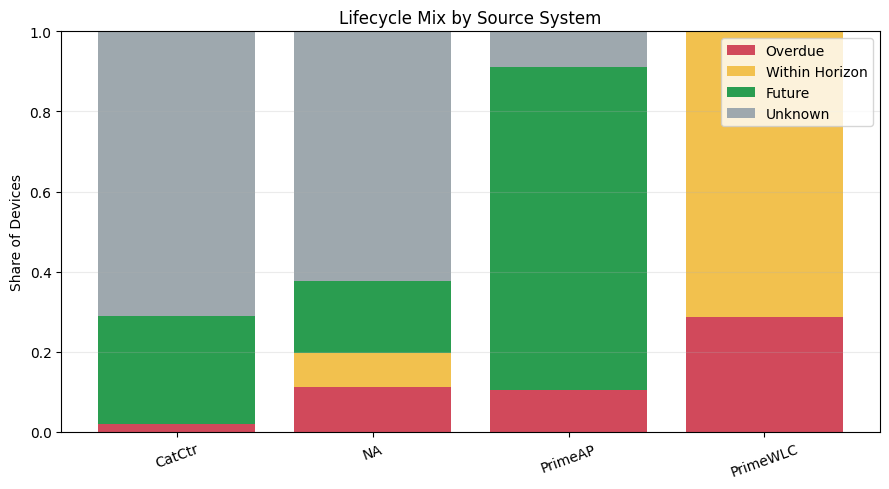

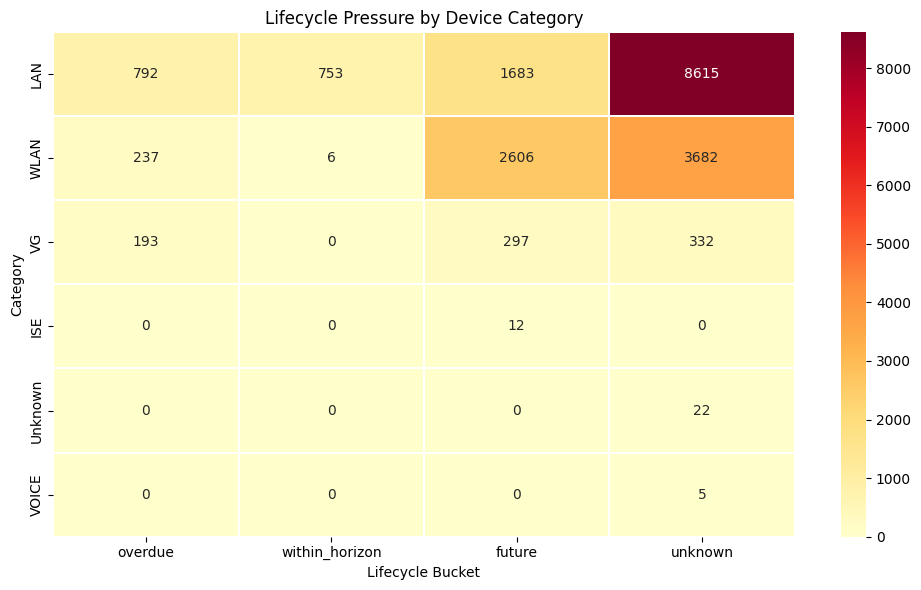

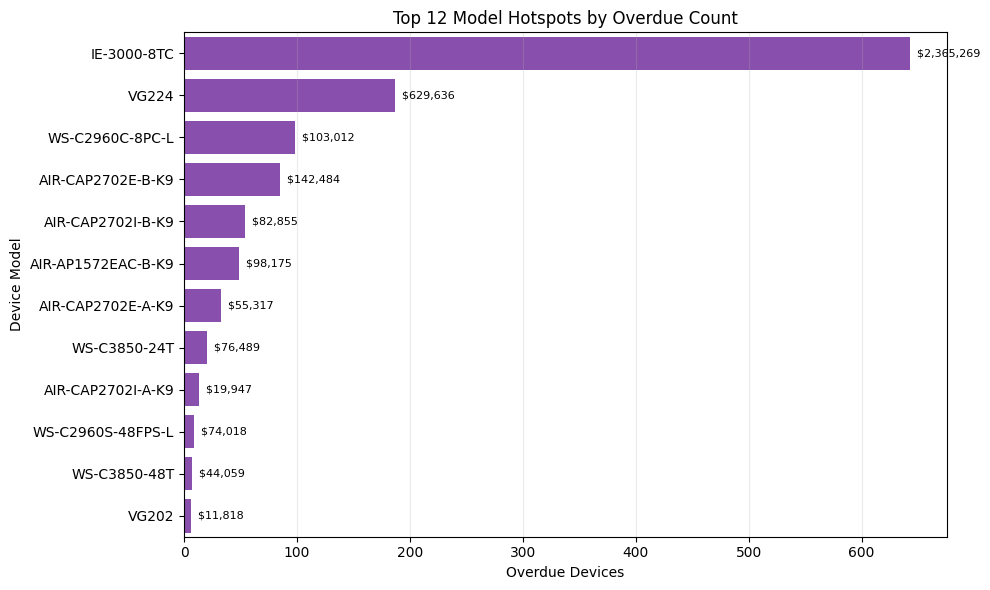

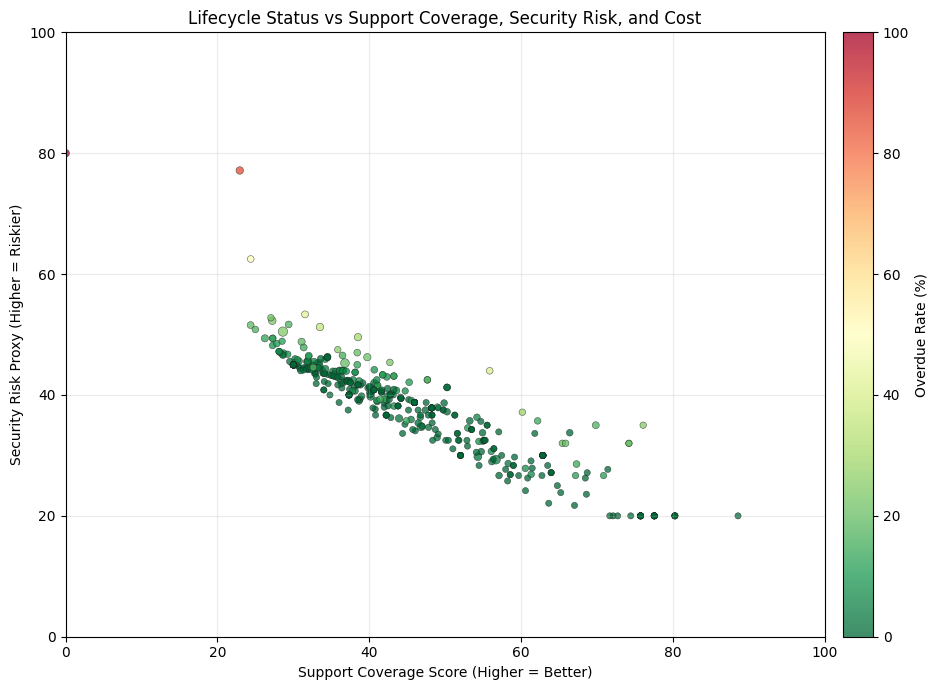

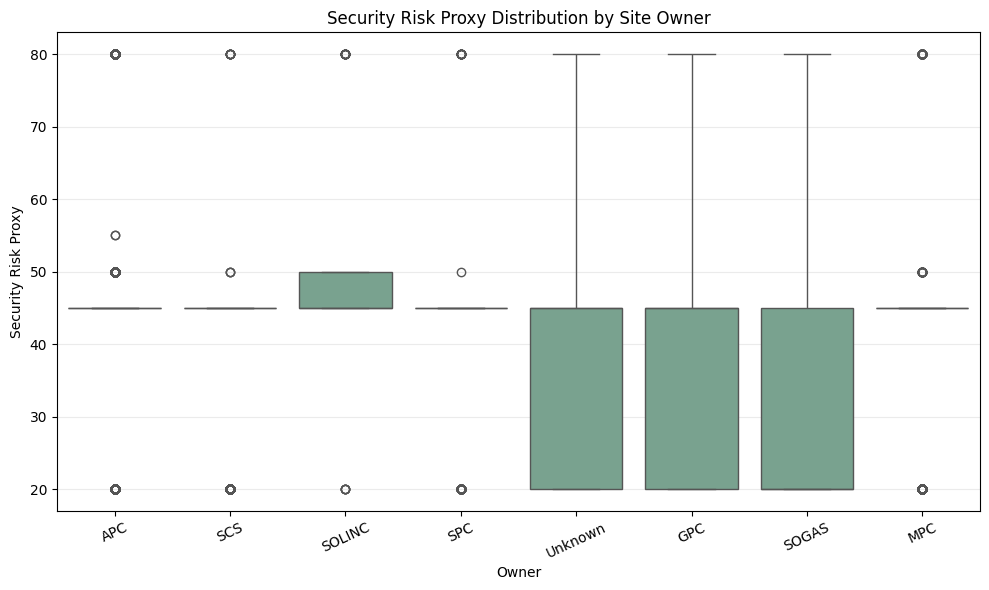

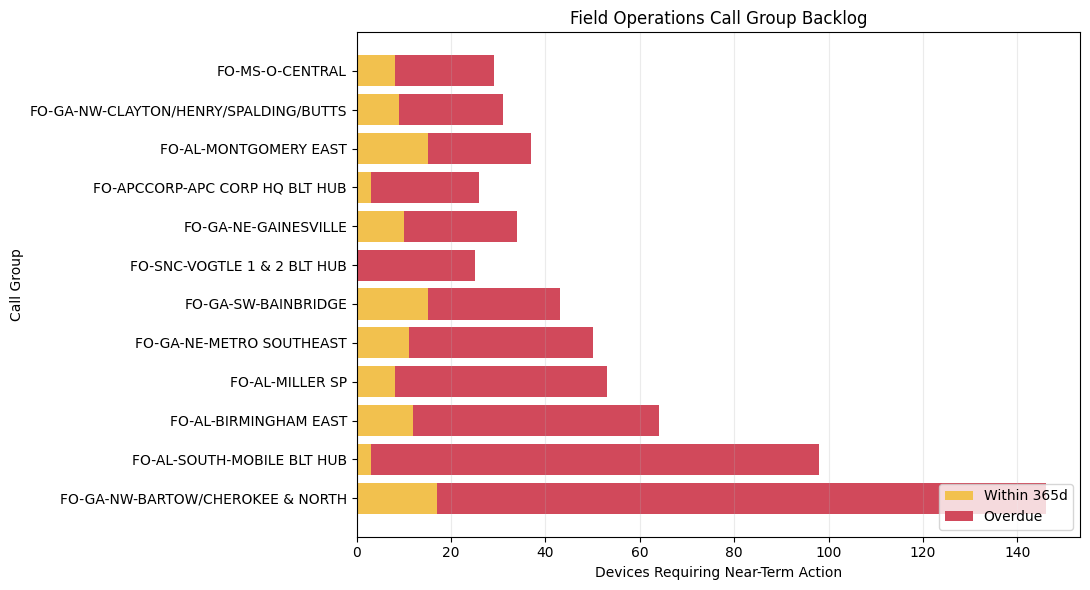

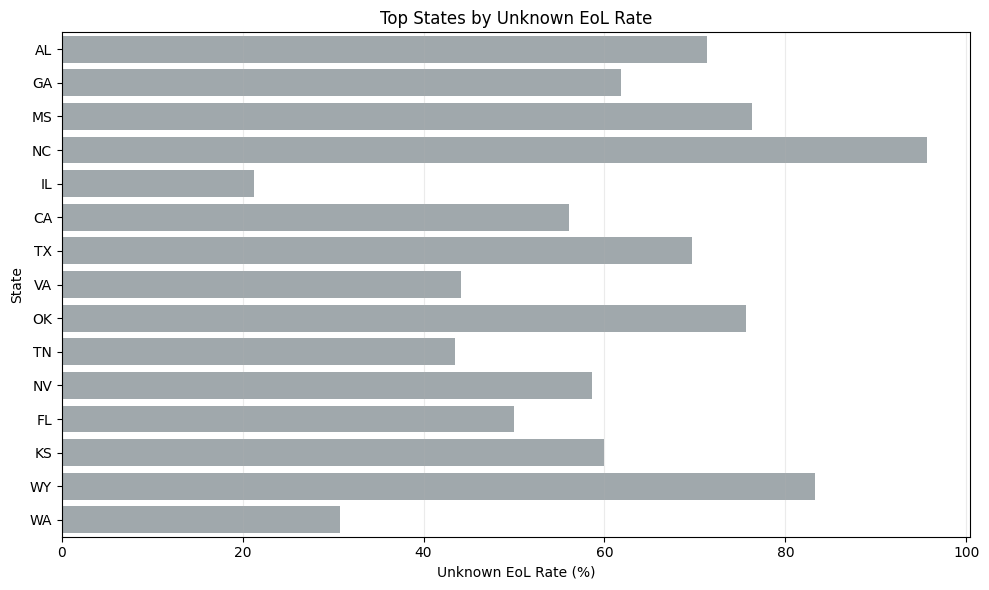

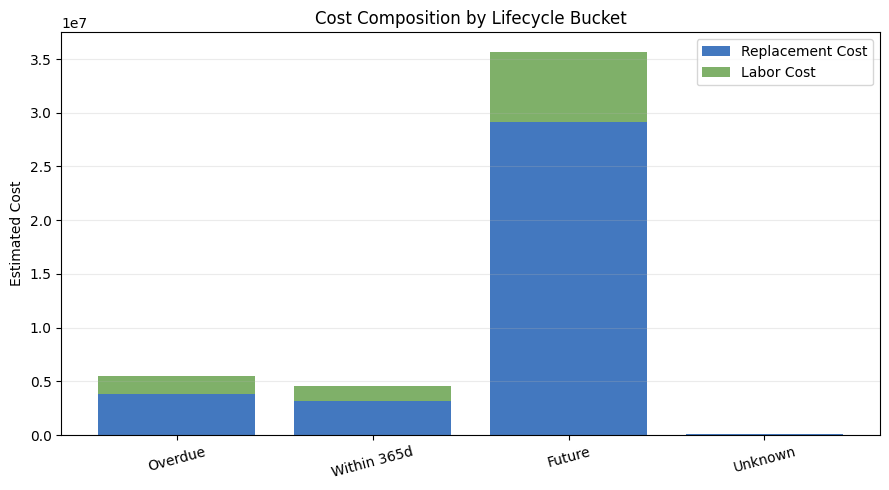

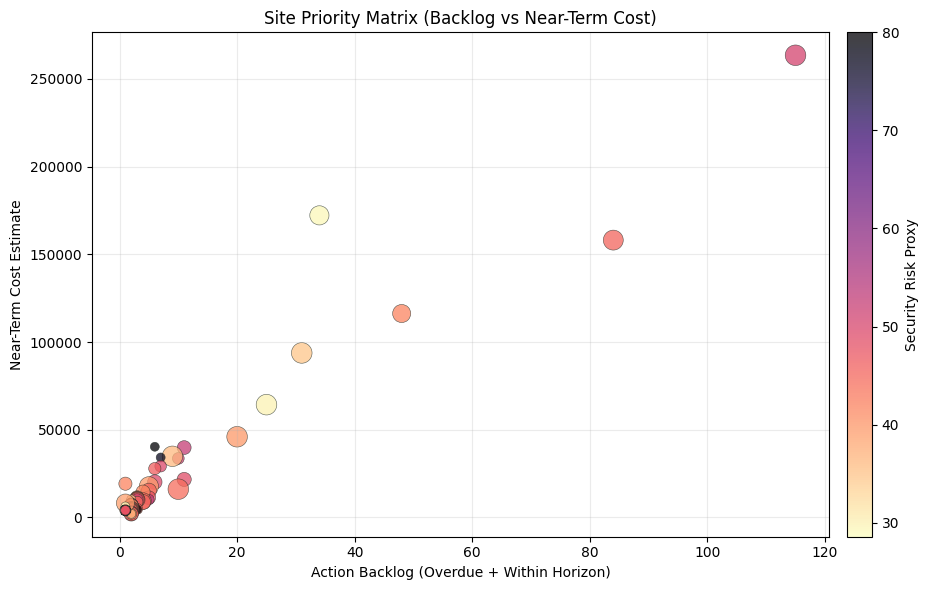

In [17]:
# Generate all appendix visuals and save to reports
suite = generate_appendix_visual_suite(
    device_dataset=device_dataset,
    horizon_days=365,
    savefig=True,
    use_streamlit=False
)